In [74]:
# @title
import pandas as pd
from google.colab import drive;
drive.mount('/content/drive')
import numpy as np
!pip install pyarrow
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv('/content/drive/MyDrive/Contents/heart_disease_uci.csv')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [76]:
df['age']

,age
0,63
1,67
2,67
3,37
4,41
...,...
915,54
916,62
917,55
918,58


In [77]:
df[['age','sex']]

,age,sex
0,63,Male
1,67,Male
2,67,Male
3,37,Male
4,41,Female
...,...,...
915,54,Female
916,62,Male
917,55,Male
918,58,Male


In [78]:
df.loc[0,"age"]

np.int64(63)

In [79]:
df.iloc[0,3]

'Cleveland'

In [80]:
df.loc[0:9]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


In [81]:
# filtering
df[df['age']>18]
df[(df['age'] >50) & (df['sex'] == 'M')]
df[(df['age']>50) | (df['sex']=='M')]
df.query('age > 50 and sex == "M"') # same thing different way

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num


In [82]:
df[df['age'] > 50]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [83]:
#indexing and filtering
#printing column names
df.columns
df['dataset']

,dataset
0,Cleveland
1,Cleveland
2,Cleveland
3,Cleveland
4,Cleveland
...,...
915,VA Long Beach
916,VA Long Beach
917,VA Long Beach
918,VA Long Beach


In [84]:
#groupby
df.groupby('sex')['age'].mean()

,age
sex,
Female,52.474227
Male,53.787879


In [85]:
#groupby
df.groupby('sex')['age'].agg(['mean', 'count', 'std'])

,mean,count,std
sex,,,
Female,52.474227,194,9.496214
Male,53.787879,726,9.392685


In [86]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [87]:
df.groupby(['sex','dataset'])['age'].mean()

sex     dataset      
Female  Cleveland        55.721649
        Hungary          47.654321
        Switzerland      56.800000
        VA Long Beach    57.833333
Male    Cleveland        53.710145
        Hungary          47.985849
        Switzerland      55.185841
        VA Long Beach    59.396907
Name: age, dtype: float64

In [88]:
df.pivot_table(values='age', index='sex', columns='dataset', aggfunc='mean')

dataset,Cleveland,Hungary,Switzerland,VA Long Beach
sex,,,,
Female,55.721649,47.654321,56.800000,57.833333
Male,53.710145,47.985849,55.185841,59.396907


In [89]:
#sorting and inspecting
df.sort_values('age', ascending=False).head(4)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
751,752,77,Male,VA Long Beach,asymptomatic,124.0,171.0,False,st-t abnormality,110.0,True,2.0,upsloping,NaN,NaN,3
161,162,77,Male,Cleveland,asymptomatic,125.0,304.0,False,lv hypertrophy,162.0,True,0.0,upsloping,3.0,normal,4
257,258,76,Female,Cleveland,non-anginal,140.0,197.0,False,st-t abnormality,116.0,False,1.1,flat,0.0,normal,0
845,846,76,Male,VA Long Beach,non-anginal,104.0,NaN,False,lv hypertrophy,120.0,False,3.5,downsloping,NaN,NaN,4


In [90]:
df['sex'].value_counts()

,count
sex,
Male,726
Female,194


In [91]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [92]:
df[df['slope'].isnull()]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
303,304,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,NaN,NaN,NaN,0
304,305,29,Male,Hungary,atypical angina,120.0,243.0,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
305,306,29,Male,Hungary,atypical angina,140.0,NaN,False,normal,170.0,False,0.0,NaN,NaN,NaN,0
306,307,30,Female,Hungary,typical angina,170.0,237.0,False,st-t abnormality,170.0,False,0.0,NaN,NaN,fixed defect,0
307,308,31,Female,Hungary,atypical angina,100.0,219.0,False,st-t abnormality,150.0,False,0.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [93]:
df.isnull().mean()*100

,0
id,0.000000
age,0.000000
sex,0.000000
dataset,0.000000
cp,0.000000
trestbps,6.413043
chol,3.260870
fbs,9.782609
restecg,0.217391
thalch,5.978261


In [94]:
df[df['ca'].isnull()]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
166,167,52,Male,Cleveland,non-anginal,138.0,223.0,False,normal,169.0,False,0.0,upsloping,NaN,normal,0
192,193,43,Male,Cleveland,asymptomatic,132.0,247.0,True,lv hypertrophy,143.0,True,0.1,flat,NaN,reversable defect,1
287,288,58,Male,Cleveland,atypical angina,125.0,220.0,False,normal,144.0,False,0.4,flat,NaN,reversable defect,0
302,303,38,Male,Cleveland,non-anginal,138.0,175.0,False,normal,173.0,False,0.0,upsloping,NaN,normal,0
303,304,28,Male,Cleveland,atypical angina,130.0,132.0,False,lv hypertrophy,185.0,False,0.0,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [95]:
df['chol'].dtype


dtype('float64')

In [96]:
df['chol'].mean()

np.float64(199.13033707865168)

In [97]:
df['chol'].mean()

np.float64(199.13033707865168)

In [98]:
df['chol'].median()

223.0

In [99]:
df['chol'].skew()


np.float64(-0.6138360897370758)

<Axes: >

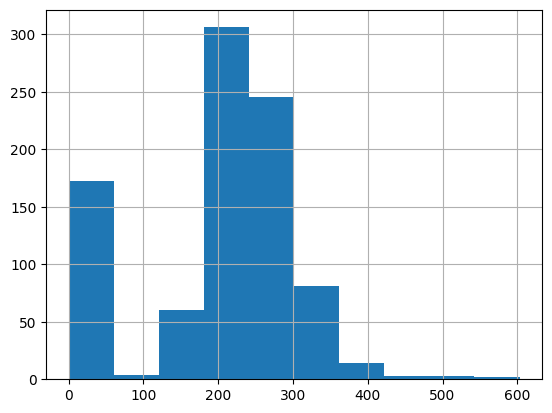

In [100]:
df['chol'].hist()

In [101]:
df['chol'].sort_values().head(15)


,chol
819,0.0
822,0.0
818,0.0
785,0.0
783,0.0
784,0.0
812,0.0
781,0.0
787,0.0
774,0.0


<Axes: >

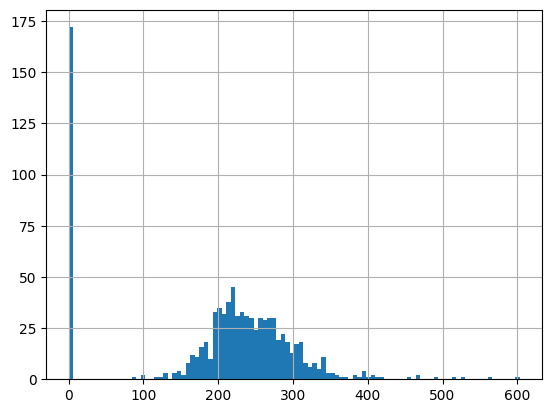

In [102]:
df['chol'].hist(bins=100)

In [103]:
df[df['chol']==0]['chol'].skew()

np.float64(0.0)

In [104]:
df[df['chol']>0]['chol'].skew()

np.float64(1.3148668578248883)

<Axes: >

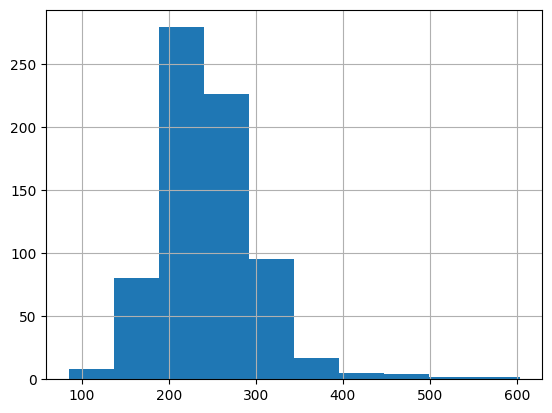

In [105]:
df[df['chol']>0]['chol'].hist()

In [106]:
# okay so cholestoral cannot be zero and therefore the zero is a placeholder for null value
df['chol']= df['chol'].replace(0,np.nan)

In [107]:
df['chol'].isnull().sum()

np.int64(202)

In [108]:
df['chol'].skew()


np.float64(1.3148668578248883)

<Axes: >

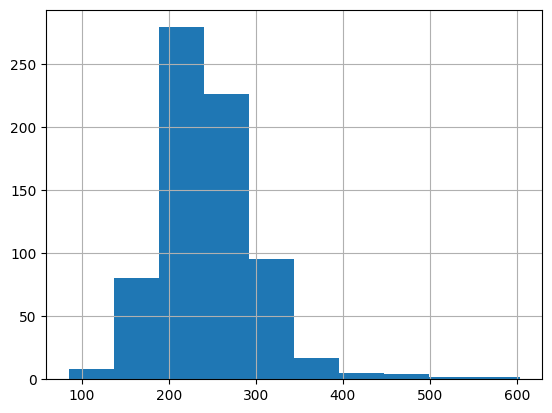

In [109]:
df['chol'].hist()

In [110]:
df['chol'].mean()

np.float64(246.83286908077994)

In [111]:
df['chol'].median()

239.5

In [112]:
df['chol']= df['chol'].fillna(df['chol'].median())

In [113]:
df['chol'].isnull().sum()

np.int64(0)

In [114]:
df['chol'].mean()

np.float64(245.22282608695653)

In [115]:
df['chol'].median()

239.5

In [116]:
df['chol'].skew()

np.float64(1.572905326744683)

In [117]:
df[df['ca'].isnull()]['sex'].value_counts(normalize=True)

,proportion
sex,
Male,0.841244
Female,0.158756


In [118]:
df[df['ca'].notnull()]['sex'].value_counts(normalize=True)

,proportion
sex,
Male,0.686084
Female,0.313916


In [119]:
df['sex'].value_counts(normalize=True)

,proportion
sex,
Male,0.78913
Female,0.21087


In [120]:
Q1= df['chol'].quantile(0.25)
Q3 = df['chol'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['chol'] < lower) | (df['chol'] > upper)]
display(outliers)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
38,39,55,Male,Cleveland,asymptomatic,132.0,353.0,False,normal,132.0,True,1.2,flat,1.0,reversable defect,3
48,49,65,Female,Cleveland,non-anginal,140.0,417.0,True,lv hypertrophy,157.0,False,0.8,upsloping,1.0,normal,0
75,76,65,Female,Cleveland,non-anginal,160.0,360.0,False,lv hypertrophy,151.0,False,0.8,upsloping,0.0,normal,0
93,94,44,Female,Cleveland,non-anginal,108.0,141.0,False,normal,175.0,False,0.6,flat,0.0,normal,0
113,114,43,Female,Cleveland,asymptomatic,132.0,341.0,True,lv hypertrophy,136.0,True,3.0,flat,0.0,reversable defect,2
121,122,63,Female,Cleveland,asymptomatic,150.0,407.0,False,lv hypertrophy,154.0,False,4.0,flat,3.0,reversable defect,4
152,153,67,Female,Cleveland,non-anginal,115.0,564.0,False,lv hypertrophy,160.0,False,1.6,flat,0.0,reversable defect,0
173,174,62,Female,Cleveland,asymptomatic,140.0,394.0,False,lv hypertrophy,157.0,False,1.2,flat,0.0,normal,0
181,182,56,Female,Cleveland,asymptomatic,134.0,409.0,False,lv hypertrophy,150.0,True,1.9,flat,2.0,reversable defect,2


In [121]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [122]:
z = (df['chol'] - df['chol'].mean()) / df['chol'].std()
outliers_z = df[abs(z) >3]
outliers

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
38,39,55,Male,Cleveland,asymptomatic,132.0,353.0,False,normal,132.0,True,1.2,flat,1.0,reversable defect,3
48,49,65,Female,Cleveland,non-anginal,140.0,417.0,True,lv hypertrophy,157.0,False,0.8,upsloping,1.0,normal,0
75,76,65,Female,Cleveland,non-anginal,160.0,360.0,False,lv hypertrophy,151.0,False,0.8,upsloping,0.0,normal,0
93,94,44,Female,Cleveland,non-anginal,108.0,141.0,False,normal,175.0,False,0.6,flat,0.0,normal,0
113,114,43,Female,Cleveland,asymptomatic,132.0,341.0,True,lv hypertrophy,136.0,True,3.0,flat,0.0,reversable defect,2
121,122,63,Female,Cleveland,asymptomatic,150.0,407.0,False,lv hypertrophy,154.0,False,4.0,flat,3.0,reversable defect,4
152,153,67,Female,Cleveland,non-anginal,115.0,564.0,False,lv hypertrophy,160.0,False,1.6,flat,0.0,reversable defect,0
173,174,62,Female,Cleveland,asymptomatic,140.0,394.0,False,lv hypertrophy,157.0,False,1.2,flat,0.0,normal,0
181,182,56,Female,Cleveland,asymptomatic,134.0,409.0,False,lv hypertrophy,150.0,True,1.9,flat,2.0,reversable defect,2


In [123]:
df.duplicated().sum()

np.int64(0)

In [124]:
df[df.duplicated(subset=['id'],keep=False)]

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num


In [125]:
df = pd.get_dummies(df, columns=['cp', 'thal'])
df.head()

,id,age,sex,dataset,trestbps,chol,fbs,restecg,thalch,exang,...,slope,ca,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,thal_fixed defect,thal_normal,thal_reversable defect
0,1,63,Male,Cleveland,145.0,233.0,True,lv hypertrophy,150.0,False,...,downsloping,0.0,0,False,False,False,True,True,False,False
1,2,67,Male,Cleveland,160.0,286.0,False,lv hypertrophy,108.0,True,...,flat,3.0,2,True,False,False,False,False,True,False
2,3,67,Male,Cleveland,120.0,229.0,False,lv hypertrophy,129.0,True,...,flat,2.0,1,True,False,False,False,False,False,True
3,4,37,Male,Cleveland,130.0,250.0,False,normal,187.0,False,...,downsloping,0.0,0,False,False,True,False,False,True,False
4,5,41,Female,Cleveland,130.0,204.0,False,lv hypertrophy,172.0,False,...,upsloping,0.0,0,False,True,False,False,False,True,False


In [126]:
order_map = {'upsloping': 0, 'flat': 1, 'downsloping': 2}
df['slope_encoded'] = df['slope'].map(order_map)

In [127]:
df['slope_encoded'].value_counts()


,count
slope_encoded,
1.0,345
0.0,203
2.0,63


In [128]:
scaler = StandardScaler()
df['age_scaled']= scaler.fit_transform(df[['age']])
df[['age', 'age_scaled']].describe()

,age,age_scaled
count,920.000000,9.200000e+02
mean,53.510870,6.178632e-17
std,9.424685,1.000544e+00
min,28.000000,-2.708286e+00
25%,47.000000,-6.912073e-01
50%,54.000000,5.192709e-02
75%,60.000000,6.888994e-01
max,77.000000,2.493654e+00


In [129]:
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 70], labels=['20-30', '30-40', '40-50', ' 50-60', '60-70'])
df['age_group'].value_counts()

,count
age_group,
50-60,382
40-50,224
60-70,197
30-40,88
20-30,5


In [130]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect',
       'slope_encoded', 'age_scaled', 'age_group'],
      dtype='object')

In [131]:
#handeling large file efficiently
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      920 non-null    int64   
 1   age                     920 non-null    int64   
 2   sex                     920 non-null    object  
 3   dataset                 920 non-null    object  
 4   trestbps                861 non-null    float64 
 5   chol                    920 non-null    float64 
 6   fbs                     830 non-null    object  
 7   restecg                 918 non-null    object  
 8   thalch                  865 non-null    float64 
 9   exang                   865 non-null    object  
 10  oldpeak                 858 non-null    float64 
 11  slope                   611 non-null    object  
 12  ca                      309 non-null    float64 
 13  num                     920 non-null    int64   
 14  cp_asymptomatic         92

In [132]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect',
       'slope_encoded', 'age_scaled', 'age_group'],
      dtype='object')

In [133]:
df.memory_usage(deep=True)

,0
Index,132
id,7360
age,7360
sex,49148
dataset,53820
trestbps,7360
chol,7360
fbs,32760
restecg,53848
thalch,7360


In [134]:
for col in ['sex', 'dataset', 'restecg', 'slope', 'fbs','exang']:
  df[col] = df[col].astype('category')
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      920 non-null    int64   
 1   age                     920 non-null    int64   
 2   sex                     920 non-null    category
 3   dataset                 920 non-null    category
 4   trestbps                861 non-null    float64 
 5   chol                    920 non-null    float64 
 6   fbs                     830 non-null    category
 7   restecg                 918 non-null    category
 8   thalch                  865 non-null    float64 
 9   exang                   865 non-null    category
 10  oldpeak                 858 non-null    float64 
 11  slope                   611 non-null    category
 12  ca                      309 non-null    float64 
 13  num                     920 non-null    int64   
 14  cp_asymptomatic         92

In [135]:
df.head()

,id,age,sex,dataset,trestbps,chol,fbs,restecg,thalch,exang,...,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,thal_fixed defect,thal_normal,thal_reversable defect,slope_encoded,age_scaled,age_group
0,1,63,Male,Cleveland,145.0,233.0,True,lv hypertrophy,150.0,False,...,False,False,False,True,True,False,False,2.0,1.007386,60-70
1,2,67,Male,Cleveland,160.0,286.0,False,lv hypertrophy,108.0,True,...,True,False,False,False,False,True,False,1.0,1.432034,60-70
2,3,67,Male,Cleveland,120.0,229.0,False,lv hypertrophy,129.0,True,...,True,False,False,False,False,False,True,1.0,1.432034,60-70
3,4,37,Male,Cleveland,130.0,250.0,False,normal,187.0,False,...,False,False,True,False,False,True,False,2.0,-1.752828,30-40
4,5,41,Female,Cleveland,130.0,204.0,False,lv hypertrophy,172.0,False,...,False,True,False,False,False,True,False,0.0,-1.328180,40-50


In [136]:
df['sex'].head()

,sex
0,Male
1,Male
2,Male
3,Male
4,Female


In [137]:
df['sex'].cat.codes.head()

,0
0,1
1,1
2,1
3,1
4,0


In [138]:
chunk_iter = pd.read_csv('/content/drive/MyDrive/Contents/heart_disease_uci.csv', chunksize=100)

for chunk in chunk_iter:
    print(chunk.shape)

(100, 16)
(100, 16)
(100, 16)
(100, 16)
(100, 16)
(100, 16)
(100, 16)
(100, 16)
(100, 16)
(20, 16)


In [139]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer' if df[col].dtype == 'int64' else 'float')

In [140]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   id                      920 non-null    int16   
 1   age                     920 non-null    int8    
 2   sex                     920 non-null    category
 3   dataset                 920 non-null    category
 4   trestbps                861 non-null    float32 
 5   chol                    920 non-null    float32 
 6   fbs                     830 non-null    category
 7   restecg                 918 non-null    category
 8   thalch                  865 non-null    float32 
 9   exang                   865 non-null    category
 10  oldpeak                 858 non-null    float32 
 11  slope                   611 non-null    category
 12  ca                      309 non-null    float32 
 13  num                     920 non-null    int8    
 14  cp_asymptomatic         92

In [141]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect',
       'slope_encoded', 'age_scaled', 'age_group'],
      dtype='object')

In [142]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect',
       'slope_encoded', 'age_scaled', 'age_group'],
      dtype='object')

In [143]:
df.to_parquet('/content/drive/MyDrive/Contents/heart_disease_cleaned.parquet')

In [144]:
df = pd.read_parquet('/content/drive/MyDrive/Contents/heart_disease_cleaned.parquet')

In [145]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'trestbps', 'chol', 'fbs', 'restecg',
       'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'num', 'cp_asymptomatic',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'thal_fixed defect', 'thal_normal', 'thal_reversable defect',
       'slope_encoded', 'age_scaled', 'age_group'],
      dtype='object')